# Sanity Check
Sanity check the `map_converter.ipynb`. Sometimes, the centerline generated is not great, such as what you see for `Spielberg_map`. In these cases, you can increase the interpolation interval in `map_converter.ipynb`, and then clean manually.

Then, you can use this book to sanity check again the points.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from PIL import Image
import os
import pandas as pd

In [3]:
MAP_NAME = "race3"

In [4]:

if os.path.exists(os.path.join(os.getcwd(), f"maps/{MAP_NAME}/{MAP_NAME}_map.png")):
    map_img_path = f"maps/{MAP_NAME}/{MAP_NAME}_map.png"
elif os.path.exists(os.path.join(os.getcwd(), f"maps/{MAP_NAME}/{MAP_NAME}_map.pgm")):
    map_img_path = f"maps/{MAP_NAME}/{MAP_NAME}_map.pgm"
# else:

#     raise Exception(f"Map {os.path.join(os.getcwd(), f'maps/{MAP_NAME}/{MAP_NAME}_map')} not found!")
# map_img_path = '/Users/bryanalfaro/Documents/Problem_Sets/f1_final/f1tenth_gym/maps/levine/levine_map.png'
# map_yaml_path = '/Users/bryanalfaro/Documents/Problem_Sets/f1_final/f1tenth_gym/maps/levine/levine_map.yaml'
map_yaml_path = f"maps/{MAP_NAME}/{MAP_NAME}_map.yaml"
map_img = np.array(Image.open(map_img_path).transpose(Image.FLIP_TOP_BOTTOM))
map_img = map_img.astype(np.float64)

# load map yaml
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        print(ex)

# calculate map parameters
orig_x = origin[0]
orig_y = origin[1]
# ??? Should be 0
orig_s = np.sin(origin[2])
orig_c = np.cos(origin[2])


In [14]:
raw_data = pd.read_csv(f"maps/{MAP_NAME}/{MAP_NAME}_raceline.csv", delimiter=';')
print(raw_data.keys())
x = raw_data["x_m"].values
y = raw_data["y_m"].values
# wr = raw_data["w_tr_right_m"].values
# wl = raw_data["w_tr_left_m"].values

x -= orig_x
y -= orig_y

x /= map_resolution
y /= map_resolution

Index(['#s_m', 'x_m', 'y_m', 'psi_rad', 'kappa_radpm', 'vx_mps', 'ax_mps2'], dtype='object')


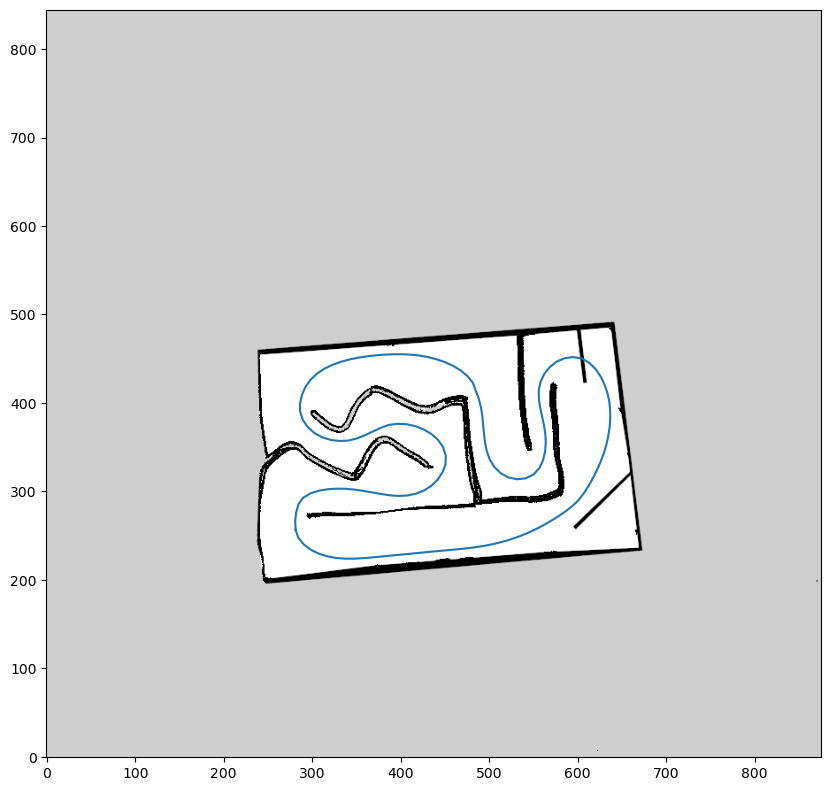

In [15]:
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap="gray", origin="lower")
plt.plot(x,y)

[45.696 45.    45.696 ... 39.    36.    33.   ]


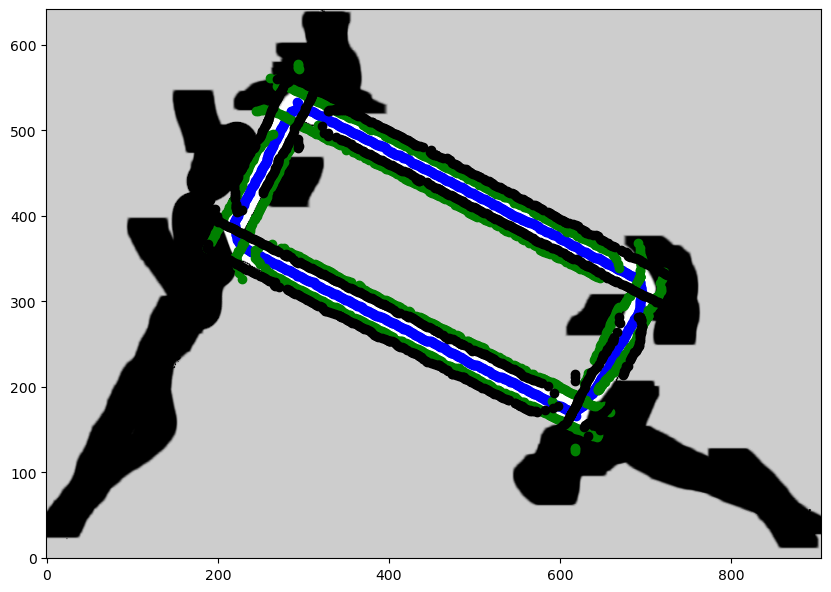

In [21]:
# TODO: Add track width visualization, to make sure it's accurate
def get_yaw(x, y):
    yaw = np.zeros_like(x)
    N = len(yaw)
    for i in range(N):
        yaw[i] = np.arctan2(y[(i+1)%N] - y[i], x[(i+1)%N] - x[i])
    return yaw

yaw = get_yaw(x, y)
raw_data = pd.read_csv(f"maps/{MAP_NAME}/{MAP_NAME}_centerline.csv")
wr = raw_data["w_tr_right_m"].values
wr *= 3
wr /= map_resolution
wl = raw_data["w_tr_left_m"].values
wl /= map_resolution
wl *= 3
print(wr)
x_r = x + wr*np.cos(yaw)
y_r = y + wr*np.sin(yaw)
x_l = x - wl*np.cos(yaw)
y_l = y - wl*np.sin(yaw)
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap="gray", origin="lower")
plt.scatter(x,y, color='b')
plt.scatter(x_r, y_r, color='g')
plt.scatter(x_l, y_l, c='k')